In [1]:
# ============================================================
# PHASE 16 — CELL 1
# Imports
# ============================================================

import os
import re
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports successful.")

Imports successful.


In [3]:
# ============================================================
# PHASE 16 — CELL 2
# Project root
# ============================================================

PROJECT_ROOT = Path(
    r"D:\downloads\misleading-health-infographic-detection"
)

assert PROJECT_ROOT.exists(), (
    f"Project root not found:\n{PROJECT_ROOT}"
)

print("Project root:")
print(PROJECT_ROOT)

print("\n✓ Project root verified.")

Project root:
D:\downloads\misleading-health-infographic-detection

✓ Project root verified.


In [4]:
# ============================================================
# PHASE 16 — CELL 3
# Output directories
# ============================================================

PHASE16_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase16"
)

CLASSIFICATION_DIR = (
    PHASE16_DIR
    / "classifications"
)

MANIFEST_DIR = (
    PHASE16_DIR
    / "manifests"
)

METRICS_DIR = (
    PHASE16_DIR
    / "metrics"
)

VIS_DIR = (
    PHASE16_DIR
    / "visualizations"
)

REPORTS_DIR = (
    PHASE16_DIR
    / "reports"
)

for directory in [
    PHASE16_DIR,
    CLASSIFICATION_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 16 directories created.")

print(PHASE16_DIR)

Phase 16 directories created.
D:\downloads\misleading-health-infographic-detection\outputs\phase16


In [5]:
# ============================================================
# PHASE 16 — CELL 4
# Load Phase 15 evidence-level explanations
# ============================================================

PHASE15_INPUT = (
    PROJECT_ROOT
    / "outputs"
    / "phase15"
    / "manifests"
    / "evidence_level_explanations.csv"
)

assert PHASE15_INPUT.exists(), (
    f"Phase 15 input not found:\n{PHASE15_INPUT}"
)

df = pd.read_csv(
    PHASE15_INPUT
)

print("Phase 15 data loaded.")

print(
    "Shape:",
    df.shape
)

display(
    df.head()
)

Phase 15 data loaded.
Shape: (70, 19)


,claim_id,record_key,image_path,label,source,phase11_split,claim_text,claim_type,evidence_source,evidence_id,evidence_title,evidence_text,evidence_url,evidence_score,evidence_relevance,overlap_terms,overlap_count,explanation_category,explanation
0,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,PubMed,36951564,COVID-19 vaccine booster dose hesitancy among ...,Vaccination is an important tool for controlli...,https://pubmed.ncbi.nlm.nih.gov/36951564/,0.8571,HIGH_RELEVANCE,"[""campaign"", ""help"", ""hesitance"", ""purpose"", ""...",5,STRONGLY_RELEVANT_RETRIEVAL,"Claim: The purpose of this campaign is, ""to he..."
1,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,PubMed,12170548,[National preparedness for biological mass cas...,"Species of plants and animals, as well as nati...",https://pubmed.ncbi.nlm.nih.gov/12170548/,0.8571,HIGH_RELEVANCE,"[""campaign"", ""help"", ""purpose"", ""reduce""]",4,STRONGLY_RELEVANT_RETRIEVAL,"Claim: The purpose of this campaign is, ""to he..."
2,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,PubMed,37084298,Using the increasing vaccination model and the...,COVID-19 vaccination programmes have helped re...,https://pubmed.ncbi.nlm.nih.gov/37084298/,0.7143,HIGH_RELEVANCE,"[""help"", ""purpose"", ""reduce""]",3,STRONGLY_RELEVANT_RETRIEVAL,"Claim: The purpose of this campaign is, ""to he..."
3,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,PubMed,36302397,Vaccination Trends and Family-Level Characteri...,Assess family-level factors associated with ch...,https://pubmed.ncbi.nlm.nih.gov/36302397/,0.4286,MODERATE_RELEVANCE,"[""help"", ""reduce""]",2,RELEVANT_RETRIEVAL,"Claim: The purpose of this campaign is, ""to he..."
4,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,WHO,7ebd5eb146705ea5,Global,NaN,https://www.who.int/,0.0000,NO_TEXTUAL_EVIDENCE,[],0,NO_RETRIEVAL_MATCH,"Claim: The purpose of this campaign is, ""to he..."


In [6]:
# ============================================================
# PHASE 16 — CELL 5
# Inspect columns
# ============================================================

print("Columns:")

for i, column in enumerate(
    df.columns,
    start=1
):
    print(
        f"{i:02d}. {column}"
    )

Columns:
01. claim_id
02. record_key
03. image_path
04. label
05. source
06. phase11_split
07. claim_text
08. claim_type
09. evidence_source
10. evidence_id
11. evidence_title
12. evidence_text
13. evidence_url
14. evidence_score
15. evidence_relevance
16. overlap_terms
17. overlap_count
18. explanation_category
19. explanation


In [7]:
# ============================================================
# PHASE 16 — CELL 6
# Clean fields
# ============================================================

TEXT_COLUMNS = [
    "claim_text",
    "claim_type",
    "evidence_source",
    "evidence_title",
    "evidence_text",
    "evidence_url",
    "explanation",
]

for column in TEXT_COLUMNS:

    if column in df.columns:

        df[column] = (
            df[column]
            .fillna("")
            .astype(str)
            .str.strip()
        )


df["evidence_score"] = pd.to_numeric(
    df["evidence_score"],
    errors="coerce"
).fillna(0.0)


print("Cleaning complete.")
print("Rows:", len(df))

Cleaning complete.
Rows: 70


In [8]:
# ============================================================
# PHASE 16 — CELL 7
# Parse overlap terms
# ============================================================

def parse_list(value):

    if isinstance(
        value,
        list
    ):
        return value

    if value is None:
        return []

    try:

        if pd.isna(value):
            return []

    except Exception:
        pass

    text = str(value).strip()

    if not text:
        return []

    try:

        parsed = json.loads(text)

        if isinstance(
            parsed,
            list
        ):
            return [
                str(x).strip()
                for x in parsed
                if str(x).strip()
            ]

    except Exception:
        pass

    if text.startswith("[") and text.endswith("]"):

        text = text[1:-1]

        items = [
            x.strip().strip("'\"")
            for x in text.split(",")
        ]

        return [
            x for x in items
            if x
        ]

    return [
        x.strip()
        for x in text.split(",")
        if x.strip()
    ]


df["overlap_terms_list"] = (
    df["overlap_terms"]
    .apply(parse_list)
)

print("Overlap terms parsed.")

Overlap terms parsed.


In [9]:
# ============================================================
# PHASE 16 — CELL 8
# Build claim-level dataset
# ============================================================

claim_rows = []

for claim_id, group in df.groupby(
    "claim_id"
):

    group = group.sort_values(
        "evidence_score",
        ascending=False
    )

    first = group.iloc[0]

    all_evidence_text = " ".join(
        group[
            "evidence_text"
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    all_titles = " ".join(
        group[
            "evidence_title"
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    all_overlap_terms = []

    for terms in group[
        "overlap_terms_list"
    ]:

        all_overlap_terms.extend(
            terms
        )

    all_overlap_terms = sorted(
        set(
            x.lower().strip()
            for x in all_overlap_terms
            if str(x).strip()
        )
    )

    claim_rows.append({

        "claim_id": claim_id,

        "record_key": first[
            "record_key"
        ],

        "image_path": first[
            "image_path"
        ],

        "label": first[
            "label"
        ],

        "source": first[
            "source"
        ],

        "phase11_split": first[
            "phase11_split"
        ],

        "claim_text": first[
            "claim_text"
        ],

        "claim_type": first[
            "claim_type"
        ],

        "evidence_count": len(
            group
        ),

        "best_evidence_score": float(
            group[
                "evidence_score"
            ].max()
        ),

        "mean_evidence_score": float(
            group[
                "evidence_score"
            ].mean()
        ),

        "evidence_sources": sorted(
            set(
                group[
                    "evidence_source"
                ]
                .tolist()
            )
        ),

        "evidence_text": all_evidence_text,

        "evidence_titles": all_titles,

        "overlap_terms": all_overlap_terms,
    })


claims_df = pd.DataFrame(
    claim_rows
)

print(
    "Claim-level dataset created."
)

print(
    "Claims:",
    len(claims_df)
)

display(
    claims_df.head()
)

Claim-level dataset created.
Claims: 14


,claim_id,record_key,image_path,label,source,phase11_split,claim_text,claim_type,evidence_count,best_evidence_score,mean_evidence_score,evidence_sources,evidence_text,evidence_titles,overlap_terms
0,claim13b_000000,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"The purpose of this campaign is, ""to help redu...",unknown,5,0.8571,0.57142,"[PubMed, WHO]",Vaccination is an important tool for controlli...,COVID-19 vaccine booster dose hesitancy among ...,"[campaign, help, hesitance, purpose, reduce]"
1,claim13b_000001,record_000050,D:\downloads\misleading-health-infographic-det...,0,MMCoVar,MMCoVar,"get the vaccine."" That is a direct quote",general_health,5,0.0000,0.00000,[WHO],,Global South-East Asia Europe Western Pacific ...,[]
2,claim13b_000002,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,Each vial contains 5 doses of 0.5 mL,quantitative,5,0.7500,0.65000,[PubMed],Subcutaneous immunotherapy is an effective all...,Evidence-based dosing of maintenance subcutane...,"[doses, each, vial]"
3,claim13b_000003,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,No Preservative Each vial contains 5 doses of ...,quantitative,5,0.0000,0.00000,[WHO],,Global South-East Asia Europe Western Pacific ...,[]
4,claim13b_000004,record_000062,D:\downloads\misleading-health-infographic-det...,1,MMCoVar,MMCoVar,Each vial contains 5 doses of 0.5 mL Janssen C...,quantitative,5,0.0000,0.00000,[WHO],,Global South-East Asia Europe Western Pacific ...,[]


In [10]:
# ============================================================
# PHASE 16 — CELL 10
# Deception pattern dictionaries
# ============================================================

DECEPTION_PATTERNS = {

    "UNSUPPORTED_OR_WEAKLY_SUPPORTED": [

        "no evidence",
        "without evidence",
        "unproven",
        "not proven",
        "unsupported",
    ],

    "EXAGGERATED_OR_ABSOLUTE": [

        "always",
        "never",
        "guaranteed",
        "guarantee",
        "completely",
        "100%",
        "all",
        "none",
        "miracle",
        "miracle cure",
        "instant cure",
        "cures",
        "cure",
        "perfectly safe",
        "zero risk",
    ],

    "FEAR_OR_ALARM_APPEAL": [

        "deadly",
        "fatal",
        "death",
        "danger",
        "dangerous",
        "warning",
        "emergency",
        "threat",
        "terrifying",
        "scary",
        "life-threatening",
        "killer",
    ],

    "PROMOTIONAL_OR_PERSUASIVE": [

        "buy",
        "purchase",
        "get",
        "try",
        "best",
        "recommended",
        "don't miss",
        "limited",
        "offer",
        "order",
        "contact us",
        "visit us",
        "learn more",
        "click here",
        "share this",
    ],

    "AUTHORITY_OR_TESTIMONIAL": [

        "doctors say",
        "doctor says",
        "experts say",
        "expert says",
        "scientists say",
        "scientist says",
        "researchers say",
        "researcher says",
        "study proves",
        "studies prove",
        "according to doctors",
        "according to experts",
    ],

    "MISSING_CONTEXT_OR_GENERALIZATION": [

        "everyone",
        "everybody",
        "all people",
        "regardless of",
        "no matter",
        "in all cases",
        "for everyone",
        "anyone can",
        "works for everyone",
        "works for all",
    ],
}

In [11]:
# ============================================================
# PHASE 16 — CELL 11
# Quantitative language detection
# ============================================================

PERCENTAGE_PATTERN = re.compile(
    r"\b\d+(?:\.\d+)?\s*%"
)

NUMBER_PATTERN = re.compile(
    r"\b\d+(?:\.\d+)?\b"
)

COMPARISON_PATTERNS = [
    "more than",
    "less than",
    "higher than",
    "lower than",
    "increase",
    "decrease",
    "reduction",
    "increase by",
    "decrease by",
    "times more",
    "times less",
    "odds",
    "risk",
    "percent",
]


def detect_quantitative_language(
    text
):

    text = str(text).lower()

    findings = []

    percentages = (
        PERCENTAGE_PATTERN
        .findall(text)
    )

    if percentages:

        findings.extend(
            percentages
        )

    numbers = (
        NUMBER_PATTERN
        .findall(text)
    )

    if numbers:

        findings.extend(
            [
                f"NUMBER:{x}"
                for x in numbers[:10]
            ]
        )

    for pattern in COMPARISON_PATTERNS:

        if pattern in text:

            findings.append(
                f"COMPARISON:{pattern}"
            )

    return sorted(
        set(findings)
    )


claims_df[
    "quantitative_patterns"
] = (
    claims_df[
        "claim_text"
    ]
    .apply(
        detect_quantitative_language
    )
)

print(
    "Quantitative detection complete."
)

display(
    claims_df[
        [
            "claim_id",
            "claim_text",
            "quantitative_patterns",
        ]
    ]
)

Quantitative detection complete.


,claim_id,claim_text,quantitative_patterns
0,claim13b_000000,"The purpose of this campaign is, ""to help redu...",[]
1,claim13b_000001,"get the vaccine."" That is a direct quote",[]
2,claim13b_000002,Each vial contains 5 doses of 0.5 mL,"[NUMBER:0.5, NUMBER:5]"
3,claim13b_000003,No Preservative Each vial contains 5 doses of ...,"[NUMBER:0.5, NUMBER:5]"
4,claim13b_000004,Each vial contains 5 doses of 0.5 mL Janssen C...,"[NUMBER:0.5, NUMBER:19, NUMBER:5]"
5,claim13b_000005,contains 6 doses of 0.3 mL,"[NUMBER:0.3, NUMBER:6]"
6,claim13b_000006,COVID-19 Vaccine contains 6 doses of 0.3 mL,"[NUMBER:0.3, NUMBER:19, NUMBER:6]"
7,claim13b_000007,"The purpose of this campaign is, ""to help redu...",[]
8,claim13b_000008,"get the vaccine."" That is a direct quote",[]
9,claim13b_000009,Each vial contains 5 doses of 0.5 mL,"[NUMBER:0.5, NUMBER:5]"


In [12]:
# ============================================================
# PHASE 16 — CELL 12
# Rule-based deception classifier
# ============================================================

def classify_deception(
    claim_text,
    claim_type,
    evidence_score,
    quantitative_patterns
):

    text = str(
        claim_text
    ).lower()

    claim_type_text = str(
        claim_type
    ).lower()

    matched_types = []
    triggers = []

    # --------------------------------------------------------
    # Pattern-based classifications
    # --------------------------------------------------------

    for deception_type, patterns in (
        DECEPTION_PATTERNS.items()
    ):

        matches = []

        for pattern in patterns:

            if pattern.lower() in text:

                matches.append(
                    pattern
                )

        if matches:

            matched_types.append(
                deception_type
            )

            triggers.extend(
                [
                    f"{deception_type}:{x}"
                    for x in matches
                ]
            )

    # --------------------------------------------------------
    # Quantitative / statistical content
    # --------------------------------------------------------

    if quantitative_patterns:

        matched_types.append(
            "QUANTITATIVE_OR_STATISTICAL_CLAIM"
        )

        triggers.extend(
            [
                f"QUANTITATIVE:{x}"
                for x in quantitative_patterns
            ]
        )

    # --------------------------------------------------------
    # Weak evidence retrieval
    # --------------------------------------------------------

    if float(evidence_score) < 0.30:

        matched_types.append(
            "WEAKLY_SUPPORTED_OR_UNVERIFIED"
        )

        triggers.append(
            "LOW_RETRIEVAL_RELEVANCE"
        )

    # --------------------------------------------------------
    # Claim type information
    # --------------------------------------------------------

    if (
        "cta" in claim_type_text
        or "campaign" in claim_type_text
    ):

        matched_types.append(
            "PROMOTIONAL_OR_PERSUASIVE"
        )

        triggers.append(
            "CLAIM_TYPE"
        )

    # --------------------------------------------------------
    # Remove duplicates
    # --------------------------------------------------------

    matched_types = sorted(
        set(matched_types)
    )

    triggers = sorted(
        set(triggers)
    )

    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    if not matched_types:

        matched_types = [
            "NO_CLEAR_DECEPTION_PATTERN"
        ]

    # --------------------------------------------------------
    # Confidence
    # --------------------------------------------------------

    pattern_count = len(
        matched_types
    )

    if (
        "NO_CLEAR_DECEPTION_PATTERN"
        in matched_types
    ):

        confidence = 0.20

    elif pattern_count >= 3:

        confidence = 0.85

    elif pattern_count == 2:

        confidence = 0.70

    else:

        confidence = 0.55

    return (
        matched_types,
        triggers,
        confidence
    )

In [13]:
# ============================================================
# PHASE 16 — CELL 13
# Apply deception classifier
# ============================================================

classification_results = []

for _, row in claims_df.iterrows():

    (
        deception_types,
        triggers,
        confidence
    ) = classify_deception(

        row["claim_text"],

        row["claim_type"],

        row["best_evidence_score"],

        row["quantitative_patterns"],
    )

    classification_results.append({

        "claim_id":
            row["claim_id"],

        "deception_types":
            deception_types,

        "trigger_patterns":
            triggers,

        "classification_confidence":
            confidence,
    })


classification_df = pd.DataFrame(
    classification_results
)

claims_df = claims_df.merge(
    classification_df,
    on="claim_id",
    how="left"
)

print(
    "Deception classification complete."
)

display(
    claims_df[
        [
            "claim_id",
            "claim_text",
            "deception_types",
            "classification_confidence",
        ]
    ]
)

Deception classification complete.


,claim_id,claim_text,deception_types,classification_confidence
0,claim13b_000000,"The purpose of this campaign is, ""to help redu...",[NO_CLEAR_DECEPTION_PATTERN],0.20
1,claim13b_000001,"get the vaccine."" That is a direct quote","[PROMOTIONAL_OR_PERSUASIVE, WEAKLY_SUPPORTED_O...",0.70
2,claim13b_000002,Each vial contains 5 doses of 0.5 mL,[QUANTITATIVE_OR_STATISTICAL_CLAIM],0.55
3,claim13b_000003,No Preservative Each vial contains 5 doses of ...,"[QUANTITATIVE_OR_STATISTICAL_CLAIM, WEAKLY_SUP...",0.70
4,claim13b_000004,Each vial contains 5 doses of 0.5 mL Janssen C...,"[QUANTITATIVE_OR_STATISTICAL_CLAIM, WEAKLY_SUP...",0.70
5,claim13b_000005,contains 6 doses of 0.3 mL,[QUANTITATIVE_OR_STATISTICAL_CLAIM],0.55
6,claim13b_000006,COVID-19 Vaccine contains 6 doses of 0.3 mL,[QUANTITATIVE_OR_STATISTICAL_CLAIM],0.55
7,claim13b_000007,"The purpose of this campaign is, ""to help redu...",[NO_CLEAR_DECEPTION_PATTERN],0.20
8,claim13b_000008,"get the vaccine."" That is a direct quote","[PROMOTIONAL_OR_PERSUASIVE, WEAKLY_SUPPORTED_O...",0.70
9,claim13b_000009,Each vial contains 5 doses of 0.5 mL,[QUANTITATIVE_OR_STATISTICAL_CLAIM],0.55


In [14]:
# ============================================================
# PHASE 16 — CELL 14
# Primary deception type
# ============================================================

PRIMARY_PRIORITY = [
    "EXAGGERATED_OR_ABSOLUTE",
    "FEAR_OR_ALARM_APPEAL",
    "QUANTITATIVE_OR_STATISTICAL_CLAIM",
    "MISSING_CONTEXT_OR_GENERALIZATION",
    "AUTHORITY_OR_TESTIMONIAL",
    "PROMOTIONAL_OR_PERSUASIVE",
    "UNSUPPORTED_OR_WEAKLY_SUPPORTED",
    "WEAKLY_SUPPORTED_OR_UNVERIFIED",
    "NO_CLEAR_DECEPTION_PATTERN",
]


def choose_primary_type(
    deception_types
):

    if not isinstance(
        deception_types,
        list
    ):
        return "NO_CLEAR_DECEPTION_PATTERN"

    for category in PRIMARY_PRIORITY:

        if category in deception_types:

            return category

    return deception_types[0]


claims_df[
    "primary_deception_type"
] = (
    claims_df[
        "deception_types"
    ]
    .apply(
        choose_primary_type
    )
)

print(
    "Primary deception type created."
)

display(
    claims_df[
        [
            "claim_id",
            "primary_deception_type",
            "classification_confidence",
        ]
    ]
)

Primary deception type created.


,claim_id,primary_deception_type,classification_confidence
0,claim13b_000000,NO_CLEAR_DECEPTION_PATTERN,0.20
1,claim13b_000001,PROMOTIONAL_OR_PERSUASIVE,0.70
2,claim13b_000002,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.55
3,claim13b_000003,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.70
4,claim13b_000004,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.70
5,claim13b_000005,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.55
6,claim13b_000006,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.55
7,claim13b_000007,NO_CLEAR_DECEPTION_PATTERN,0.20
8,claim13b_000008,PROMOTIONAL_OR_PERSUASIVE,0.70
9,claim13b_000009,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.55


In [15]:
# ============================================================
# PHASE 16 — CELL 15
# Generate classification explanation
# ============================================================

def build_classification_explanation(
    row
):

    deception_types = row[
        "deception_types"
    ]

    triggers = row[
        "trigger_patterns"
    ]

    if not isinstance(
        deception_types,
        list
    ):
        deception_types = []

    if not isinstance(
        triggers,
        list
    ):
        triggers = []

    if (
        "NO_CLEAR_DECEPTION_PATTERN"
        in deception_types
    ):

        explanation = (
            "No predefined deception pattern "
            "was detected in the extracted claim "
            "using the Phase 16 rule-based classifier."
        )

    else:

        readable_types = [
            x.replace(
                "_",
                " "
            ).title()
            for x in deception_types
        ]

        explanation = (
            "The claim was assigned the following "
            "candidate deception type(s): "
            + ", ".join(
                readable_types
            )
            + ". "
        )

        if triggers:

            trigger_text = ", ".join(
                triggers[:10]
            )

            explanation += (
                "The classification was triggered "
                "by detected linguistic or quantitative "
                "patterns including: "
                + trigger_text
                + ". "
            )

        explanation += (
            "This is a rule-based candidate classification "
            "and should not be interpreted as confirmation "
            "that the claim is intentionally deceptive."
        )

    return explanation


claims_df[
    "classification_explanation"
] = claims_df.apply(
    build_classification_explanation,
    axis=1
)

display(
    claims_df[
        [
            "claim_id",
            "primary_deception_type",
            "classification_explanation",
        ]
    ]
)

,claim_id,primary_deception_type,classification_explanation
0,claim13b_000000,NO_CLEAR_DECEPTION_PATTERN,No predefined deception pattern was detected i...
1,claim13b_000001,PROMOTIONAL_OR_PERSUASIVE,The claim was assigned the following candidate...
2,claim13b_000002,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...
3,claim13b_000003,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...
4,claim13b_000004,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...
5,claim13b_000005,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...
6,claim13b_000006,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...
7,claim13b_000007,NO_CLEAR_DECEPTION_PATTERN,No predefined deception pattern was detected i...
8,claim13b_000008,PROMOTIONAL_OR_PERSUASIVE,The claim was assigned the following candidate...
9,claim13b_000009,QUANTITATIVE_OR_STATISTICAL_CLAIM,The claim was assigned the following candidate...


In [16]:
# ============================================================
# PHASE 16 — CELL 16
# Manual inspection
# ============================================================

for _, row in claims_df.iterrows():

    print("=" * 80)

    print(
        "CLAIM ID:",
        row["claim_id"]
    )

    print(
        "\nCLAIM:"
    )

    print(
        row["claim_text"]
    )

    print(
        "\nCLAIM TYPE:"
    )

    print(
        row["claim_type"]
    )

    print(
        "\nPRIMARY DECEPTION TYPE:"
    )

    print(
        row[
            "primary_deception_type"
        ]
    )

    print(
        "\nALL CANDIDATE TYPES:"
    )

    print(
        row[
            "deception_types"
        ]
    )

    print(
        "\nTRIGGERS:"
    )

    print(
        row[
            "trigger_patterns"
        ]
    )

    print(
        "\nCONFIDENCE:"
    )

    print(
        row[
            "classification_confidence"
        ]
    )

    print(
        "\nEXPLANATION:"
    )

    print(
        row[
            "classification_explanation"
        ]
    )

    print()

CLAIM ID: claim13b_000000

CLAIM:
The purpose of this campaign is, "to help reduce hesitance

CLAIM TYPE:
unknown

PRIMARY DECEPTION TYPE:
NO_CLEAR_DECEPTION_PATTERN

ALL CANDIDATE TYPES:
['NO_CLEAR_DECEPTION_PATTERN']

TRIGGERS:
[]

CONFIDENCE:
0.2

EXPLANATION:
No predefined deception pattern was detected in the extracted claim using the Phase 16 rule-based classifier.

CLAIM ID: claim13b_000001

CLAIM:
get the vaccine." That is a direct quote

CLAIM TYPE:
general_health

PRIMARY DECEPTION TYPE:
PROMOTIONAL_OR_PERSUASIVE

ALL CANDIDATE TYPES:
['PROMOTIONAL_OR_PERSUASIVE', 'WEAKLY_SUPPORTED_OR_UNVERIFIED']

TRIGGERS:
['LOW_RETRIEVAL_RELEVANCE', 'PROMOTIONAL_OR_PERSUASIVE:get']

CONFIDENCE:
0.7

EXPLANATION:
The claim was assigned the following candidate deception type(s): Promotional Or Persuasive, Weakly Supported Or Unverified. The classification was triggered by detected linguistic or quantitative patterns including: LOW_RETRIEVAL_RELEVANCE, PROMOTIONAL_OR_PERSUASIVE:get. This is a

In [17]:
# ============================================================
# PHASE 16 — CELL 17
# Classification statistics
# ============================================================

primary_type_counts = (
    claims_df[
        "primary_deception_type"
    ]
    .value_counts()
)

print(
    "Primary deception type distribution:"
)

display(
    primary_type_counts
)

Primary deception type distribution:


primary_deception_type
QUANTITATIVE_OR_STATISTICAL_CLAIM    10
NO_CLEAR_DECEPTION_PATTERN            2
PROMOTIONAL_OR_PERSUASIVE             2
Name: count, dtype: int64

In [18]:
# ============================================================
# PHASE 16 — CELL 18
# Multi-label deception type distribution
# ============================================================

all_type_counts = {}

for types in claims_df[
    "deception_types"
]:

    if not isinstance(
        types,
        list
    ):
        continue

    for deception_type in types:

        all_type_counts[
            deception_type
        ] = (
            all_type_counts.get(
                deception_type,
                0
            )
            + 1
        )


multi_label_counts = (
    pd.Series(
        all_type_counts
    )
    .sort_values(
        ascending=False
    )
)

display(
    multi_label_counts
)

QUANTITATIVE_OR_STATISTICAL_CLAIM    10
WEAKLY_SUPPORTED_OR_UNVERIFIED        6
PROMOTIONAL_OR_PERSUASIVE             2
NO_CLEAR_DECEPTION_PATTERN            2
dtype: int64

In [19]:
# ============================================================
# PHASE 16 — CELL 19
# Save classification statistics
# ============================================================

primary_stats = (
    primary_type_counts
    .rename(
        "claim_count"
    )
    .reset_index()
)

primary_stats.columns = [
    "primary_deception_type",
    "claim_count",
]

PRIMARY_STATS_FILE = (
    METRICS_DIR
    / "primary_deception_type_statistics.csv"
)

primary_stats.to_csv(
    PRIMARY_STATS_FILE,
    index=False,
    encoding="utf-8-sig"
)


multi_stats = (
    multi_label_counts
    .rename(
        "claim_count"
    )
    .reset_index()
)

multi_stats.columns = [
    "deception_type",
    "claim_count",
]

MULTI_STATS_FILE = (
    METRICS_DIR
    / "deception_type_statistics.csv"
)

multi_stats.to_csv(
    MULTI_STATS_FILE,
    index=False,
    encoding="utf-8-sig"
)


print("Saved:")
print(PRIMARY_STATS_FILE)
print(MULTI_STATS_FILE)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\primary_deception_type_statistics.csv
D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\deception_type_statistics.csv


In [20]:
# ============================================================
# PHASE 16 — CELL 20
# Classification confidence statistics
# ============================================================

confidence_stats = pd.DataFrame({
    "metric": [
        "mean_confidence",
        "median_confidence",
        "minimum_confidence",
        "maximum_confidence",
        "high_confidence_count",
        "medium_confidence_count",
        "low_confidence_count",
    ],

    "value": [

        claims_df[
            "classification_confidence"
        ].mean(),

        claims_df[
            "classification_confidence"
        ].median(),

        claims_df[
            "classification_confidence"
        ].min(),

        claims_df[
            "classification_confidence"
        ].max(),

        (
            claims_df[
                "classification_confidence"
            ] >= 0.75
        ).sum(),

        (
            (
                claims_df[
                    "classification_confidence"
                ] >= 0.50
            )
            &
            (
                claims_df[
                    "classification_confidence"
                ] < 0.75
            )
        ).sum(),

        (
            claims_df[
                "classification_confidence"
            ] < 0.50
        ).sum(),
    ],
})

display(
    confidence_stats
)

,metric,value
0,mean_confidence,0.564286
1,median_confidence,0.550000
2,minimum_confidence,0.200000
3,maximum_confidence,0.700000
4,high_confidence_count,0.000000
5,medium_confidence_count,12.000000
6,low_confidence_count,2.000000


In [21]:
# ============================================================
# PHASE 16 — CELL 21
# Save complete classification manifest
# ============================================================

CLASSIFICATION_CSV = (
    MANIFEST_DIR
    / "deception_classification_manifest.csv"
)

export_df = claims_df.copy()

export_df[
    "deception_types"
] = export_df[
    "deception_types"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

export_df[
    "trigger_patterns"
] = export_df[
    "trigger_patterns"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

export_df[
    "evidence_sources"
] = export_df[
    "evidence_sources"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

export_df[
    "overlap_terms"
] = export_df[
    "overlap_terms"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

export_df[
    "quantitative_patterns"
] = export_df[
    "quantitative_patterns"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

export_df.to_csv(
    CLASSIFICATION_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(CLASSIFICATION_CSV)

print(
    "Rows:",
    len(export_df)
)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\deception_classification_manifest.csv
Rows: 14


In [22]:
# ============================================================
# PHASE 16 — CELL 22
# Save classification JSONL
# ============================================================

CLASSIFICATION_JSONL = (
    MANIFEST_DIR
    / "deception_classification_manifest.jsonl"
)

with open(
    CLASSIFICATION_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for _, row in claims_df.iterrows():

        record = {
            "claim_id":
                row["claim_id"],

            "record_key":
                row["record_key"],

            "image_path":
                row["image_path"],

            "label":
                row["label"],

            "source":
                row["source"],

            "phase11_split":
                row["phase11_split"],

            "claim_text":
                row["claim_text"],

            "claim_type":
                row["claim_type"],

            "evidence_count":
                int(
                    row["evidence_count"]
                ),

            "best_evidence_score":
                float(
                    row[
                        "best_evidence_score"
                    ]
                ),

            "deception_types":
                row["deception_types"],

            "primary_deception_type":
                row[
                    "primary_deception_type"
                ],

            "trigger_patterns":
                row[
                    "trigger_patterns"
                ],

            "classification_confidence":
                float(
                    row[
                        "classification_confidence"
                    ]
                ),

            "classification_explanation":
                row[
                    "classification_explanation"
                ],
        }

        f.write(
            json.dumps(
                record,
                ensure_ascii=False
            )
            + "\n"
        )

print("Saved:")
print(CLASSIFICATION_JSONL)

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\deception_classification_manifest.jsonl


In [23]:
# ============================================================
# PHASE 16 — CELL 23
# Save individual classification JSON files
# ============================================================

saved_count = 0

for _, row in claims_df.iterrows():

    claim_id = str(
        row["claim_id"]
    )

    safe_claim_id = re.sub(
        r"[^a-zA-Z0-9_-]",
        "_",
        claim_id
    )

    output_file = (
        CLASSIFICATION_DIR
        / f"{safe_claim_id}.json"
    )

    record = {
        "claim_id":
            row["claim_id"],

        "record_key":
            row["record_key"],

        "claim_text":
            row["claim_text"],

        "claim_type":
            row["claim_type"],

        "deception_types":
            row["deception_types"],

        "primary_deception_type":
            row[
                "primary_deception_type"
            ],

        "trigger_patterns":
            row[
                "trigger_patterns"
            ],

        "classification_confidence":
            float(
                row[
                    "classification_confidence"
                ]
            ),

        "classification_explanation":
            row[
                "classification_explanation"
            ],
    }

    with open(
        output_file,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            record,
            f,
            indent=2,
            ensure_ascii=False
        )

    saved_count += 1


print(
    "Individual classification files:",
    saved_count
)

Individual classification files: 14


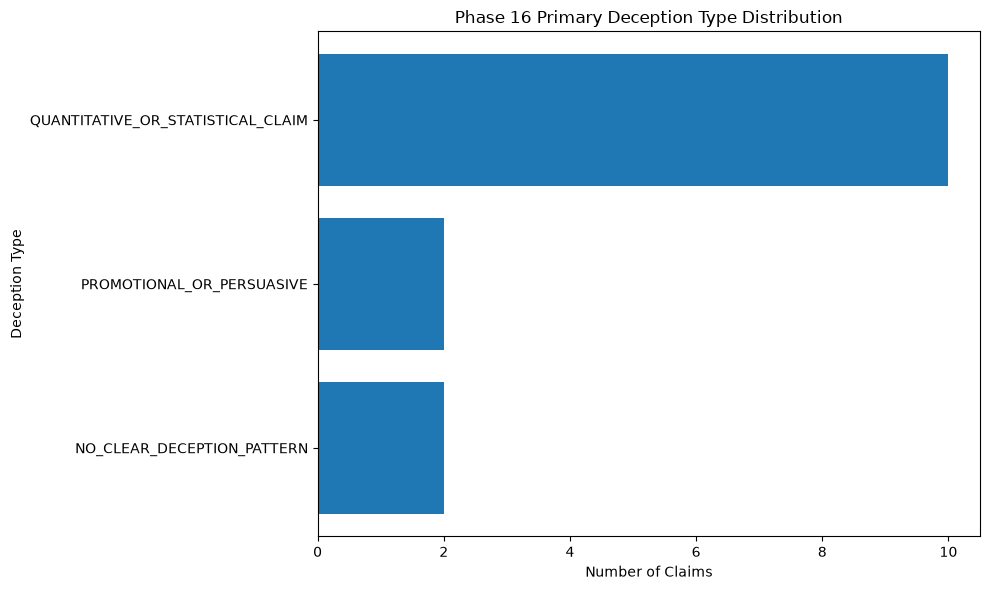

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\visualizations\primary_deception_type_distribution.png


In [24]:
# ============================================================
# PHASE 16 — CELL 24
# Primary deception type visualization
# ============================================================

plot_data = (
    claims_df[
        "primary_deception_type"
    ]
    .value_counts()
    .sort_values(
        ascending=True
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    plot_data.index,
    plot_data.values
)

plt.title(
    "Phase 16 Primary Deception Type Distribution"
)

plt.xlabel(
    "Number of Claims"
)

plt.ylabel(
    "Deception Type"
)

plt.tight_layout()

TYPE_PLOT = (
    VIS_DIR
    / "primary_deception_type_distribution.png"
)

plt.savefig(
    TYPE_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(TYPE_PLOT)

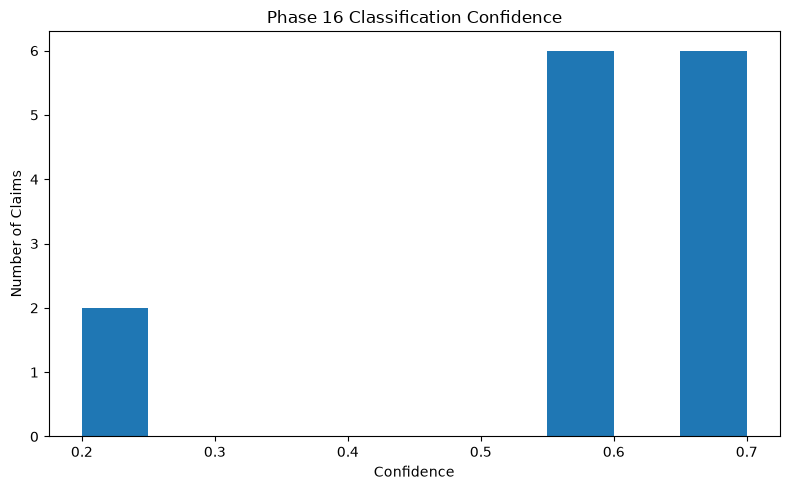

Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\visualizations\classification_confidence_distribution.png


In [25]:
# ============================================================
# PHASE 16 — CELL 25
# Classification confidence distribution
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.hist(
    claims_df[
        "classification_confidence"
    ],
    bins=10
)

plt.title(
    "Phase 16 Classification Confidence"
)

plt.xlabel(
    "Confidence"
)

plt.ylabel(
    "Number of Claims"
)

plt.tight_layout()

CONFIDENCE_PLOT = (
    VIS_DIR
    / "classification_confidence_distribution.png"
)

plt.savefig(
    CONFIDENCE_PLOT,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(CONFIDENCE_PLOT)

In [26]:
# ============================================================
# PHASE 16 — CELL 26
# Deception type vs Phase 11 label
# ============================================================

label_type_table = pd.crosstab(
    claims_df[
        "primary_deception_type"
    ],
    claims_df[
        "label"
    ]
)

display(
    label_type_table
)

LABEL_TYPE_FILE = (
    METRICS_DIR
    / "deception_type_by_phase11_label.csv"
)

label_type_table.to_csv(
    LABEL_TYPE_FILE,
    encoding="utf-8-sig"
)

print("Saved:")
print(LABEL_TYPE_FILE)

label,0,1
primary_deception_type,,
NO_CLEAR_DECEPTION_PATTERN,1,1
PROMOTIONAL_OR_PERSUASIVE,1,1
QUANTITATIVE_OR_STATISTICAL_CLAIM,5,5


Saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\deception_type_by_phase11_label.csv


In [27]:
# ============================================================
# PHASE 16 — CELL 27
# Create Phase 17 handoff
# ============================================================

PHASE17_INPUT = (
    MANIFEST_DIR
    / "phase17_ablation_evaluation_input.csv"
)

phase17_columns = [
    "claim_id",
    "record_key",
    "image_path",
    "label",
    "source",
    "phase11_split",
    "claim_text",
    "claim_type",
    "evidence_count",
    "best_evidence_score",
    "mean_evidence_score",
    "deception_types",
    "primary_deception_type",
    "trigger_patterns",
    "classification_confidence",
    "classification_explanation",
]

phase17_df = claims_df[
    phase17_columns
].copy()

phase17_df[
    "deception_types"
] = phase17_df[
    "deception_types"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

phase17_df[
    "trigger_patterns"
] = phase17_df[
    "trigger_patterns"
].apply(
    lambda x: json.dumps(
        x,
        ensure_ascii=False
    )
)

phase17_df.to_csv(
    PHASE17_INPUT,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Phase 17 input created:"
)

print(
    PHASE17_INPUT
)

print(
    "Rows:",
    len(phase17_df)
)

Phase 17 input created:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\phase17_ablation_evaluation_input.csv
Rows: 14


In [28]:
# ============================================================
# PHASE 16 — CELL 28
# Generate Phase 16 report
# ============================================================

REPORT_FILE = (
    REPORTS_DIR
    / "phase16_report.txt"
)

total_claims = len(
    claims_df
)

unique_primary_types = (
    claims_df[
        "primary_deception_type"
    ]
    .nunique()
)

mean_confidence = (
    claims_df[
        "classification_confidence"
    ].mean()
)

with open(
    REPORT_FILE,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 16 — DECEPTION TYPE CLASSIFICATION REPORT\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )

    f.write(
        f"Total claims: {total_claims}\n"
    )

    f.write(
        f"Unique primary deception types: "
        f"{unique_primary_types}\n"
    )

    f.write(
        f"Mean classification confidence: "
        f"{mean_confidence:.4f}\n\n"
    )

    f.write(
        "Primary deception type distribution:\n"
    )

    for category, count in (
        claims_df[
            "primary_deception_type"
        ]
        .value_counts()
        .items()
    ):

        f.write(
            f"  {category}: {count}\n"
        )

    f.write(
        "\nIMPORTANT METHODOLOGICAL NOTE:\n"
    )

    f.write(
        "Phase 16 uses an interpretable rule-based "
        "multi-label classifier. The resulting deception "
        "types are candidate classifications derived from "
        "linguistic, quantitative, claim-type, and evidence "
        "retrieval patterns. They are not ground-truth labels "
        "and do not independently establish intentional "
        "deception.\n"
    )

    f.write(
        "\nPhase 17 should evaluate the classifier "
        "descriptively and, if manually annotated labels "
        "become available, using appropriate classification "
        "metrics.\n"
    )

print(
    "Report saved:"
)

print(
    REPORT_FILE
)

Report saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase16\reports\phase16_report.txt


In [29]:
# ============================================================
# PHASE 16 — CELL 29
# Final artifact check
# ============================================================

expected_files = [

    MANIFEST_DIR
    / "deception_classification_manifest.csv",

    MANIFEST_DIR
    / "deception_classification_manifest.jsonl",

    MANIFEST_DIR
    / "phase17_ablation_evaluation_input.csv",

    METRICS_DIR
    / "primary_deception_type_statistics.csv",

    METRICS_DIR
    / "deception_type_statistics.csv",

    METRICS_DIR
    / "deception_type_by_phase11_label.csv",

    VIS_DIR
    / "primary_deception_type_distribution.png",

    VIS_DIR
    / "classification_confidence_distribution.png",

    REPORT_FILE,
]

print("=" * 75)
print("PHASE 16 FINAL ARTIFACT CHECK")
print("=" * 75)

all_exist = True

for file_path in expected_files:

    if file_path.exists():

        print(
            "✓",
            file_path
        )

    else:

        print(
            "✗",
            file_path
        )

        all_exist = False


json_files = list(
    CLASSIFICATION_DIR.glob(
        "*.json"
    )
)

print()

print(
    "Total claims:",
    len(claims_df)
)

print(
    "Individual JSON files:",
    len(json_files)
)

print(
    "Primary deception types:",
    claims_df[
        "primary_deception_type"
    ].nunique()
)

print(
    "Mean classification confidence:",
    round(
        claims_df[
            "classification_confidence"
        ].mean(),
        4
    )
)

print()

if (
    all_exist
    and len(json_files)
    == len(claims_df)
):

    print(
        "✓ PHASE 16 COMPLETED SUCCESSFULLY"
    )

else:

    print(
        "✗ PHASE 16 IS NOT COMPLETE."
    )

PHASE 16 FINAL ARTIFACT CHECK
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\deception_classification_manifest.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\deception_classification_manifest.jsonl
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\manifests\phase17_ablation_evaluation_input.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\primary_deception_type_statistics.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\deception_type_statistics.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\metrics\deception_type_by_phase11_label.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\visualizations\primary_deception_type_distribution.png
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase16\visualizations\classification_confidence_distribution.png
✓ D:\downloads\